In [90]:
%pip install pycountry

Note: you may need to restart the kernel to use updated packages.


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [92]:
import pycountry
import pandas as pd

records = []
for c in pycountry.countries:
    records.append({
        "country_name": c.name,
        "iso3":         c.alpha_3,
        "iso2":         c.alpha_2,
        "iso_numeric":  c.numeric,
    })

df_iso = pd.DataFrame(records)
print(df_iso.shape)
print(df_iso.head())

(249, 4)
    country_name iso3 iso2 iso_numeric
0          Aruba  ABW   AW         533
1    Afghanistan  AFG   AF         004
2         Angola  AGO   AO         024
3       Anguilla  AIA   AI         660
4  Åland Islands  ALA   AX         248


In [93]:
# Index of economic freedom
df_eco_free = pd.read_csv('Data/Clean/heritage-index-of-economic-freedom.csv', skiprows=4)
# Join to get iso3 codes
df_eco_free = df_eco_free.merge(df_iso, left_on="Country", right_on="country_name", how="left")
# Limit to columns we need
df_eco_free = df_eco_free[["iso3", "Index Year", "Overall Score", "Investment Freedom", "Financial Freedom", "Tax Burden"]]
df_eco_free = df_eco_free.drop_duplicates(subset=["iso3", "Index Year"], keep="last")
df_eco_free

,iso3,Index Year,Overall Score,Investment Freedom,Financial Freedom,Tax Burden
0,ALB,2026,68.0,60.0,60.0,89.3
1,ALB,2025,66.6,60.0,60.0,88.8
2,ALB,2024,64.8,70.0,70.0,88.8
3,ALB,2023,65.3,70.0,70.0,89.1
4,ALB,2022,66.6,70.0,70.0,89.1
...,...,...,...,...,...,...
1450,GBR,1999,76.2,70.0,90.0,62.3
1451,GBR,1998,76.5,70.0,90.0,60.8
1452,GBR,1997,76.4,70.0,90.0,61.7
1453,GBR,1996,76.4,70.0,90.0,62.1


In [94]:
# Gravity (Lang + Dist)
df_gravity = pd.read_csv('Data/Clean/cepii_gravity_language.csv')
# Join to get iso3 codes for both origin and destination
# It is iso3, though we renamed to iso in data.
df_gravity = df_gravity.merge(df_iso.add_suffix('_o'), left_on="iso3_o", right_on="iso3_o", how="left")
df_gravity = df_gravity.merge(df_iso.add_suffix('_d'), left_on="iso3_d", right_on="iso3_d", how="left")
# Select only some columns
df_gravity = df_gravity[["iso3_o", "iso3_d", "year", "distance_km", "shared_border", "common_legal_origin", "language_proximity", "language_spoken_share", "common_official_language"]]
# Remove duplicates
df_gravity = df_gravity.drop_duplicates(subset=["iso3_o", "iso3_d", "year"], keep="last")
df_gravity

,iso3_o,iso3_d,year,distance_km,shared_border,common_legal_origin,language_proximity,language_spoken_share,common_official_language
0,ABW,ABW,1948,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,ABW,1949,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
4699291,ZWE,ZWE,2017,43.0,0.0,1.0,NaN,NaN,NaN
4699292,ZWE,ZWE,2018,43.0,0.0,1.0,NaN,NaN,NaN
4699293,ZWE,ZWE,2019,43.0,0.0,1.0,NaN,NaN,NaN
4699294,ZWE,ZWE,2020,42.0,0.0,1.0,NaN,NaN,NaN


In [104]:
# IMF CPIS
df_cpis = pd.read_csv('Data/Clean/IMF_CPIS.csv')
# join by iso3 codes
df_cpis = df_cpis.merge(df_iso.add_suffix("_o"), left_on="REF_AREA_LABEL", right_on="country_name_o", how="left")
# join COMP_BREAKDOWN_1_LABEL to to get iso3 to get destination country
df_cpis = df_cpis.merge(df_iso.add_suffix("_d"), left_on="COMP_BREAKDOWN_1_LABEL", right_on="country_name_d", how="left")
# Now we only keep the necessary columns
df_cpis = df_cpis[["iso3_o", "iso3_d", "year", "value"]]
# rename value to cpis
df_cpis = df_cpis.rename({"value": "cpis"}, axis=1)
# remove duplicates
df_cpis = df_cpis.drop_duplicates(subset=["iso3_o", "iso3_d", "year"], keep="last")
# Add the lagged cpis as well
df_cpis = df_cpis.sort_values(by=["iso3_o", "iso3_d", "year"])  # Ensure it's sorted before shifting
df_cpis["cpis_t-1"] = df_cpis.groupby(["iso3_o", "iso3_d"])["cpis"].shift(1)
df_cpis

,iso3_o,iso3_d,year,cpis,cpis_t-1
33870,ABW,AGO,2001,0.000000e+00,NaN
70971,ABW,AGO,2002,0.000000e+00,0.0
107218,ABW,AGO,2003,0.000000e+00,0.0
145424,ABW,AGO,2004,0.000000e+00,0.0
187656,ABW,AGO,2005,0.000000e+00,0.0
...,...,...,...,...,...
2264143,NaN,NaN,2019,5.416588e+07,NaN
2566925,NaN,NaN,2020,2.382153e+07,NaN
2876087,NaN,NaN,2021,1.581715e+07,NaN
3173904,NaN,NaN,2022,1.941212e+07,NaN


In [105]:
### FULL DATAFRAME ###
# First limit all years to minimum across all dataframes
min_year = max(df_eco_free["Index Year"].min(), df_gravity["year"].min(), df_cpis["year"].min())
print(f"Minimum year across all dataframes: {min_year}")

Minimum year across all dataframes: 1997


In [106]:
df_eco_free = df_eco_free[df_eco_free["Index Year"] >= min_year]
df_cpis = df_cpis[df_cpis["year"] >= min_year]
df_gravity = df_gravity[df_gravity["year"] >= min_year]

In [107]:
df_gravity.columns

Index(['iso3_o', 'iso3_d', 'year', 'distance_km', 'shared_border',
       'common_legal_origin', 'language_proximity', 'language_spoken_share',
       'common_official_language'],
      dtype='object')

In [108]:
df_eco_free.columns

Index(['iso3', 'Index Year', 'Overall Score', 'Investment Freedom',
       'Financial Freedom', 'Tax Burden'],
      dtype='object')

In [109]:
# Join to one dataframe
# gravity + destination eco freedom
df_full = df_gravity.merge(df_eco_free.add_suffix("_d"), left_on=["iso3_d", "year"], right_on=["iso3_d", "Index Year_d"], how="left")
# full + cpis
df_full = df_full.merge(df_cpis, left_on=["iso3_o", "iso3_d", "year"], right_on=["iso3_o", "iso3_d", "year"], how="left")
df_full

,iso3_o,iso3_d,year,distance_km,shared_border,common_legal_origin,language_proximity,language_spoken_share,common_official_language,Index Year_d,Overall Score_d,Investment Freedom_d,Financial Freedom_d,Tax Burden_d,cpis,cpis_t-1
0,ABW,ABW,1997,32.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,ABW,1998,32.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,ABW,1999,32.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,ABW,2000,32.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,ABW,2001,32.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476220,ZWE,ZWE,2017,43.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1476221,ZWE,ZWE,2018,43.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1476222,ZWE,ZWE,2019,43.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1476223,ZWE,ZWE,2020,42.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [110]:
# log the distance
df_full["log_distance_km"] = np.log(df_full["distance_km"])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


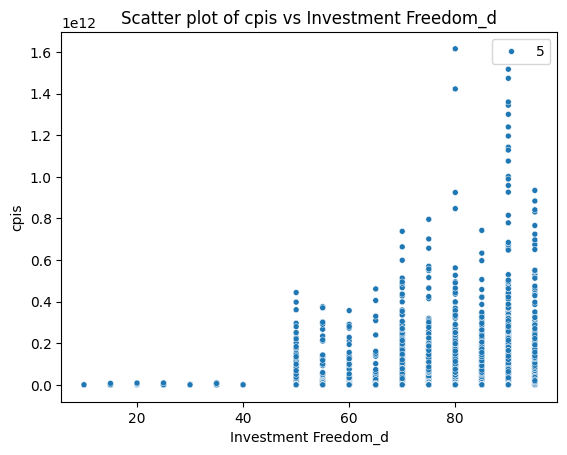

In [111]:
# scatter plot
y = "cpis"
x = "Investment Freedom_d"

sns.scatterplot(data=df_full, x=x, y=y, size=5)
plt.ylabel(y)
plt.xlabel(x)
plt.title(f"Scatter plot of {y} vs {x}")
plt.show()

**Fit gravity model**
$$\ln \Omega_{i,j,t} = \alpha_{i} + \alpha_{j} + \beta_{1} Legal_{i,j,t} + \beta_{2} \ln CPIS_{i,j,t-1} - \beta_{3} \ln Dist_{i,j} + \beta_{4} Language_{i,j} + \eta_{i,j,t}$$

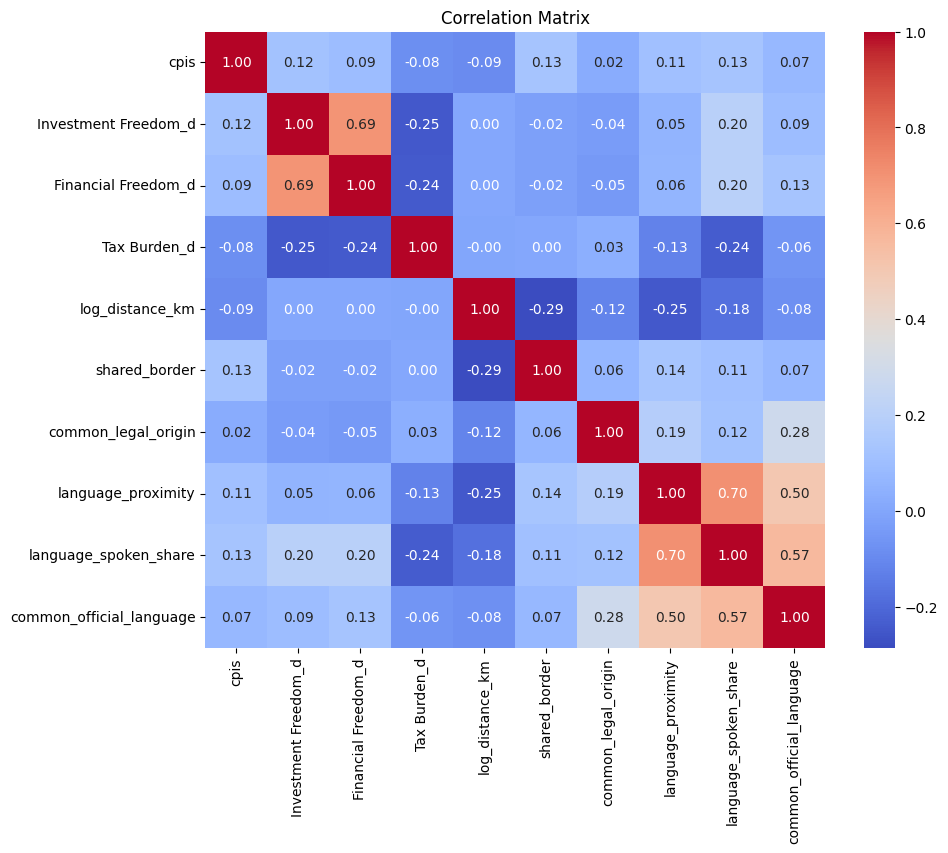

In [118]:
# seaborn heatmap of correlation matrix
corr_matrix = df_full[["cpis", "Investment Freedom_d", "Financial Freedom_d", "Tax Burden_d", "log_distance_km", "shared_border", "common_legal_origin", "language_proximity", "language_spoken_share", "common_official_language"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [122]:
import statsmodels.formula.api as smf

# Prepare estimation sample
df_est = df_full.copy()

# Drop rows with missing values in any variable used
df_est = df_est.dropna(subset=[
    "cpis", "cpis_t-1", "log_distance_km",
    "common_legal_origin", "language_proximity",
    "Investment Freedom_d", "iso3_o", "iso3_d"
])

# Only keep positive CPIS (log requires > 0)
df_est = df_est[df_est["cpis"] > 0]
df_est = df_est[df_est["cpis_t-1"] > 0]

print(f"Estimation sample: {len(df_est):,} rows, "
      f"{df_est['iso3_o'].nunique()} exporters, "
      f"{df_est['iso3_d'].nunique()} importers")

# ── OLS formula ───────────────────────────────────────────────────────────────
# Q() wraps column names with special characters (spaces, hyphens)
formula = (
    "np.log(cpis) ~ "
    "C(iso3_o) + C(iso3_d) "                    # α_i + α_j  (country FE)
    "+ common_legal_origin "                     # β_1  Legal
    "+ np.log(Q('cpis_t-1')) "                   # β_2  ln CPIS_{t-1}
    "+ log_distance_km "                         # β_3  ln Distance
    "+ language_proximity "                      # β_4  Language
    "+ Q('Investment Freedom_d')"                # β_5  Investment Freedom
)

model  = smf.ols(formula, data=df_est)
result = model.fit(cov_type="HC3")              # heteroscedasticity-robust SEs

# ── Summary (hide FE rows for readability) ───────────────────────────────────
core_vars = [v for v in result.params.index if not v.startswith("C(iso3")]
display(result.summary2(float_format="%.4f").tables[0])   # model stats
display(result.summary2(float_format="%.4f").tables[1].loc[core_vars].round(4))  # coefficients only

Estimation sample: 20,886 rows, 71 exporters, 26 importers


,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.909
1,Dependent Variable:,np.log(cpis),AIC:,62978.4899
2,Date:,2026-03-16 17:22,BIC:,63773.1733
3,No. Observations:,20886,Log-Likelihood:,-31389.
4,Df Model:,99,F-statistic:,2448.
5,Df Residuals:,20786,Prob (F-statistic):,0.00
6,R-squared:,0.909,Scale:,1.1885


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,3.7759,0.2648,14.2616,0.0000,3.2570,4.2949
common_legal_origin,0.0201,0.0189,1.0621,0.2882,-0.0170,0.0572
np.log(Q('cpis_t-1')),0.7739,0.0087,89.2910,0.0000,0.7570,0.7909
log_distance_km,-0.2065,0.0231,-8.9384,0.0000,-0.2518,-0.1612
language_proximity,0.2562,0.0620,4.1292,0.0000,0.1346,0.3778


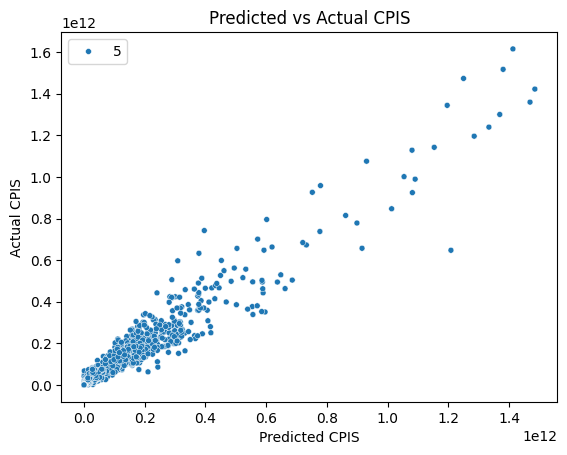

In [121]:
# scatter pred and true values
df_est["log_cpis_pred"] = result.predict(df_est)
df_est["cpis_pred"] = np.exp(df_est["log_cpis_pred"])

sns.scatterplot(data=df_est, x="cpis_pred", y="cpis", size=5)
plt.xlabel("Predicted CPIS")
plt.ylabel("Actual CPIS")
plt.title("Predicted vs Actual CPIS")
plt.show()